# 01 — LSTM Baseline
### Standard LSTM classifier — Baseline 1
> Run 00_Data_Preparation.ipynb first.

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')

✅ Device: cpu


In [2]:
with open('prepared_data.pkl','rb') as f: d = pickle.load(f)
with open('encoder.pkl','rb') as f: encoder = pickle.load(f)

X_train = torch.FloatTensor(d['X_train_seq']).to(DEVICE)
X_test  = torch.FloatTensor(d['X_test_seq']).to(DEVICE)
y_train = torch.LongTensor(d['y_train_seq']).to(DEVICE)
y_test  = torch.LongTensor(d['y_test_seq']).to(DEVICE)

NUM_CLASSES  = d['num_classes']
NUM_FEATURES = d['num_features']
TIME_STEPS   = d['TIME_STEPS']

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
print(f'✅ Data loaded. Classes: {list(encoder.classes_)}')

✅ Data loaded. Classes: ['Blade Blunt', 'Healthy', 'High Foot Pressure', 'Skip Stitches/Slip', 'Waveness']


#### LSTM Architecture

In [3]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.bn   = nn.BatchNorm1d(hidden_size)
        self.fc1  = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(32, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.bn(out[:, -1, :])
        out = self.drop(self.relu(self.fc1(out)))
        return self.fc2(out)

model = LSTMClassifier(NUM_FEATURES, hidden_size=64, num_layers=2,
                       num_classes=NUM_CLASSES).to(DEVICE)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

LSTMClassifier(
  (lstm): LSTM(66, 64, num_layers=2, batch_first=True, dropout=0.2)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (drop): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=5, bias=True)
)
Parameters: 69,445


#### Train

Epoch   1 | Train Loss: 0.4210 | Val Loss: 0.4037
Epoch   2 | Train Loss: 0.4150 | Val Loss: 0.4078
Epoch   3 | Train Loss: 0.3972 | Val Loss: 0.4323
Epoch   4 | Train Loss: 0.3928 | Val Loss: 0.4165
Epoch   5 | Train Loss: 0.3728 | Val Loss: 0.4369
Epoch   6 | Train Loss: 0.3548 | Val Loss: 0.4472
Epoch   7 | Train Loss: 0.3375 | Val Loss: 0.4774
Epoch   8 | Train Loss: 0.2904 | Val Loss: 0.4715
Epoch   9 | Train Loss: 0.2871 | Val Loss: 0.4840
Epoch  10 | Train Loss: 0.2751 | Val Loss: 0.5001
Epoch  11 | Train Loss: 0.2764 | Val Loss: 0.5165
Epoch  12 | Train Loss: 0.2656 | Val Loss: 0.5267
Epoch  13 | Train Loss: 0.2692 | Val Loss: 0.5341
Epoch  14 | Train Loss: 0.2612 | Val Loss: 0.5349
Epoch  15 | Train Loss: 0.2550 | Val Loss: 0.5459
Early stopping at epoch 16


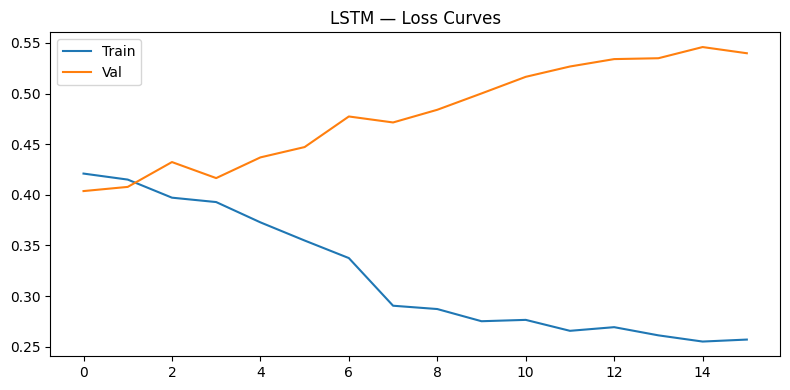

In [6]:
EPOCHS    = 100
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 15
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_test), y_test).item()
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('LSTM — Loss Curves')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_loss.png', dpi=150)
plt.show()

#### Evaluate

LSTM BASELINE RESULTS
Accuracy : 92.04%
F1 Score : 0.8823
RMSE     : 0.5439
MAE      : 0.1386

                    precision    recall  f1-score   support

       Blade Blunt       0.00      0.00      0.00        21
           Healthy       0.92      1.00      0.96       983
High Foot Pressure       0.00      0.00      0.00        22
Skip Stitches/Slip       0.00      0.00      0.00        21
          Waveness       0.00      0.00      0.00        21

          accuracy                           0.92      1068
         macro avg       0.18      0.20      0.19      1068
      weighted avg       0.85      0.92      0.88      1068



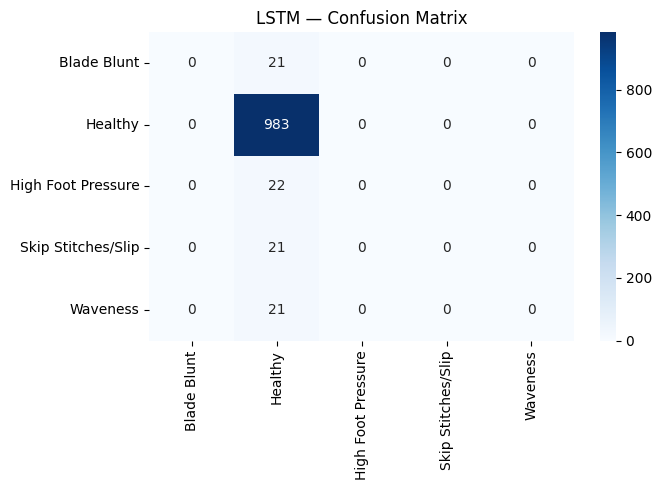

✅ Results saved to lstm_results.pkl


In [5]:
model.load_state_dict(torch.load('best_lstm.pt'))
model.eval()
with torch.no_grad():
    logits = model(X_test)
    probs  = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(probs, axis=1)
    y_true = y_test.cpu().numpy()

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print('='*50)
print('LSTM BASELINE RESULTS')
print('='*50)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('LSTM — Confusion Matrix')
plt.tight_layout()
plt.savefig('lstm_confusion.png', dpi=150)
plt.show()

lstm_results = {'model':'LSTM','accuracy':acc,'f1':f1,'rmse':rmse,'mae':mae}
with open('lstm_results.pkl','wb') as f: pickle.dump(lstm_results, f)
print('✅ Results saved to lstm_results.pkl')